# Clasificación de actividades humanas mediante CNN dual.
Este notebook realiza un pipeline completo de clasificación de actividad humana a partir de señales de acelerómetro.

El objetivo es convertir series temporales crudas en una predicción de la actividad realizada. 

Para ello vamos a utilizar las 3 señales del acelerometro (X, Y, Z), derivar de ellas la altura y un mapa de energía, y construir dos ramas de representación: una con mayor resolución temporal y otra con mayor resolución espectral. A partir de ellas, entrenaremos una red dual para reconocer las 4 actividades y evaluaremos la generalización entre sujetos con validación Leave-One-Subject-Out (LOSO).

In [1]:
import os
import numpy as np
import pandas as pd

# Visualizacion
from matplotlib import pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report

# PyTorch
import torch

## Carga de datos y validación inicial

En esta sección cargamos los datos originales y fijamos una convención de nombres más clara que la de los csv originales:

- `data`: conjunto etiquetado completo.
- `predict`: conjunto sin etiquetas para inferencia final.

In [2]:
data = pd.read_csv('data/train.csv')
predict = pd.read_csv('data/test.csv')

print('Shapes:', (data.shape, predict.shape))
print('Columns in data but not in predict:', set(data.columns) - set(predict.columns))

assert set(f'{l}{i}' for i in range(1, 201) for l in 'XYZ') == set(predict.columns)

Shapes: ((9920, 602), (5120, 600))
Columns in data but not in predict: {'LABEL', 'USER_ID'}


In [3]:
feature_cols = [c for c in predict.columns if c[:1] in {'X', 'Y', 'Z'} and c[1:].isdigit()]
feature_cols = sorted(feature_cols, key=lambda c: (c[0], int(c[1:])))

def to_nested_features(df, cols):
    nested = df[cols].copy()
    nested.columns = pd.MultiIndex.from_tuples(
        [(c[0], int(c[1:])) for c in cols],
        names=['axis', 'sample']
    )

    if 'LABEL' in df.columns and 'USER_ID' in df.columns:
        nested[("META", "LABEL")] = df["LABEL"].to_numpy()
        nested[("META", "USER_ID")] = df["USER_ID"].to_numpy()

    return nested

data = to_nested_features(data, cols=feature_cols)
predict = to_nested_features(predict, cols=feature_cols)

In [4]:
data.head()

axis           X                                                        \
sample         1          2          3         4          5          6   
0       1.582196   1.237512   1.280597  2.233266   2.312256   2.460662   
1      -0.495483  20.712166  15.711853  9.564985  -1.472089  -4.320520   
2       3.822643   7.472944   7.733851  8.054599  18.924117  19.766679   
3       2.393640   2.556407   2.561195  2.565982   2.697632   2.733537   
4       0.406919   0.672613   0.447611 -0.603197  -0.426068  -0.378195   

axis                                             ...         Z            \
sample         7         8         9         10  ...       193       194   
0       2.388853  2.226085  1.737783   1.728208  ...  4.667598  4.959622   
1      -4.806429 -4.772918 -4.507224  -3.552162  ...  0.007181 -1.800017   
2       7.489700 -3.662269  4.085943  11.616335  ...  4.382755  3.477959   
3       2.628217  2.477417  2.283533   2.106403  ...  4.200838  4.155359   
4       0.495483  0.378195  0.603197   0.505058  ...  5.146326  4.904568   

axis                                                                    META  \
sample       195       196        197        198        199        200 LABEL   
0       5.371328  5.230103   5.254040   5.225316   5.122390   4.473713     4   
1       1.180065  3.614396   8.435187  18.048045  12.013679  10.943721     1   
2      -1.077138 -7.190494 -10.105947  -5.996068  -1.632463   0.239364     1   
3       4.162540  3.997379   3.975836   4.085943   4.021315   4.028496     2   
4       4.753769  4.698715   4.696322   4.686747   3.837005   3.817856     4   

axis            
sample USER_ID  
0           13  
1           22  
2            1  
3           19  
4           22  

[5 rows x 602 columns]

## Primera visualización de nuestros datos.
Vamos a hacer una breve exploración de los datos. No vamos a entrar en detalles ni calcular estadísticas, simplemente pintaremos algunas muestras. En primer lugar lo haremos con matplotlib, pero en un resultado siguiente, tendremos un gráfico interactivo con plotly que nos permitirá explorar mejor las señales.

In [5]:
labels = { 1: "Skip", 2: "Twist", 3: "Jump", 4: "Step" }

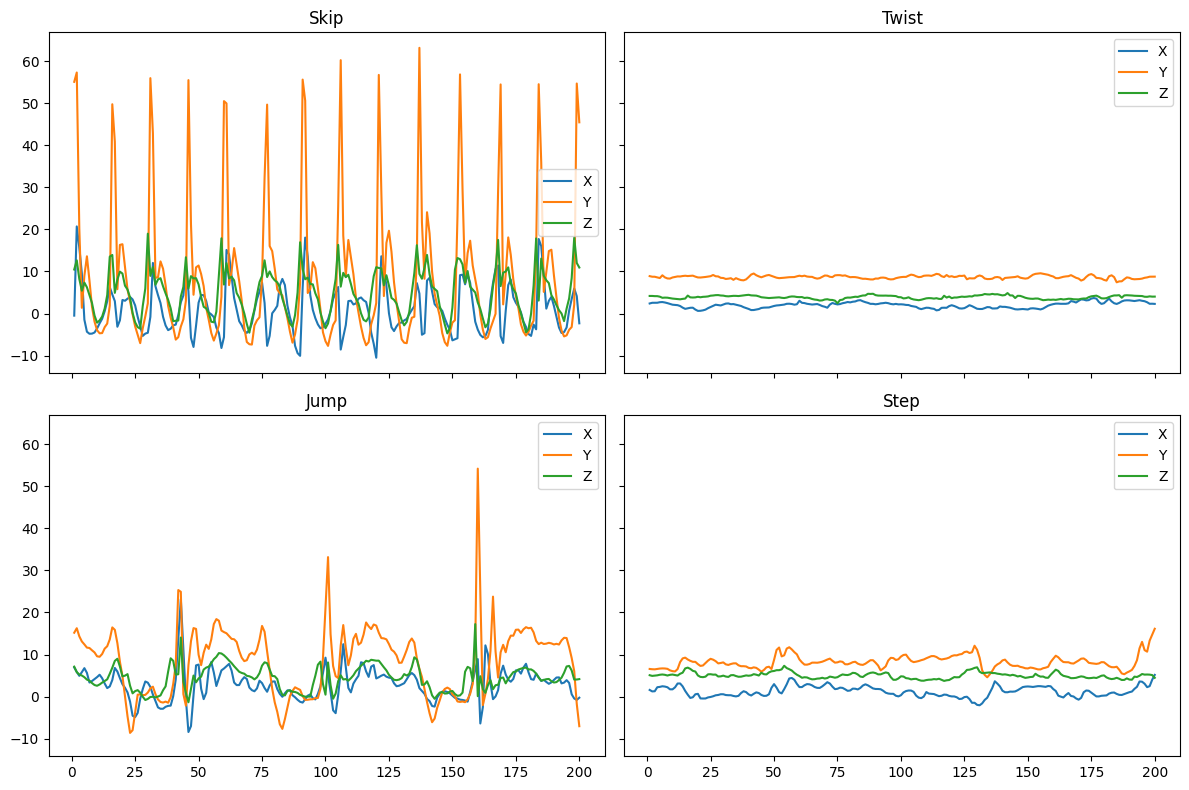

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, lbl in zip(axs.ravel(), labels.keys()):
    subset = data[data['META']['LABEL'] == lbl]
    if subset.empty:
        ax.set_title(f"{labels[lbl]} (sin muestras)")
        continue

    row = subset.iloc[0]
    ax.plot(row["X"], label="X")
    ax.plot(row["Y"], label="Y")
    ax.plot(row["Z"], label="Z")
    ax.set_title(labels[lbl])
    ax.legend()

plt.tight_layout()

Para un analisis más detallado, se ha creado este gráfico con plotly. Mediante un slider, se puede visualizar una muestra de cada clase (Skip, Twist, Jump, Step) y sus correspondientes datos de sensores. La función `make_plotly_graph` en `utils.py` se encarga de generar este gráfico interactivo (escrito en fichero aparte para mantener el notebook limpio).

In [7]:
from utils import make_plotly_graph

df_20 = data.groupby(data["META"]["LABEL"]).head(20)
make_plotly_graph(df_20, height=400, width=900)

# FASE 1: Prototipado Rápido (Hold-out)
Se usa una partición 80/20 por grupos de sujeto para validar rápidamente que el pipeline entrena y produce métricas razonables sin esperar el coste completo de LOSO.

## Partición del dataset por sujeto
Separamos el conjunto de entrenamiento en train/val asegurando que ningún usuario aparezca en ambos subconjuntos. Esto evita fuga de información entre particiones y hace que la evaluación sea más realista para este problema de generalización entre sujetos.

In [8]:
groups = data[("META", "USER_ID")].to_numpy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(data, groups=groups))

train_df = data.iloc[train_idx].reset_index(drop=True)
val_df = data.iloc[val_idx].reset_index(drop=True)

In [9]:
users_train = set(train_df[("META", "USER_ID")].unique())
users_val = set(val_df[("META", "USER_ID")].unique())
assert users_train.isdisjoint(users_val), "¡Error! Hay usuarios mezclados"

## Ingeniería de espectrogramas multirresolución
A partir de las tres señales construimos dos ramas de representación: una con mayor resolución temporal y otra con mayor resolución espectral. Además incorporamos señales derivadas de altura y un mapa de energía. Hemos pensado que esto es lo que más diferencia los 4 tipos de movimiento.

> Nota: tenemos dos formas para calcular la altura, una es integrando la aceleración y otra es utilizando la componente Z del acelerómetro. Se incluyen las 2 a la red neuronal para que ella pueda aprender a seleccionar lo que más le convenga.

In [10]:
from scipy.signal import butter, filtfilt, detrend, spectrogram

In [11]:
def get_height_signal_z_only(row_z, fs=50):
    # 1. Eliminar la gravedad
    b, a = butter(3, 0.5 / (fs / 2), btype='high')
    acc = filtfilt(b, a, row_z)

    # Primera integración: Aceleración -> Velocidad
    vel = np.cumsum(acc) * (1.0 / fs)
    vel = filtfilt(b, a, vel)

    # Segunda integración: Velocidad -> Altura
    height = np.cumsum(vel) * (1.0 / fs)
    height = filtfilt(b, a, height)

    return height

def get_height_signal_mag(row, fs=50):
    x = row['X'].values.astype(float)
    y = row['Y'].values.astype(float)
    z = row['Z'].values.astype(float)

    mag = np.sqrt(x**2 + y**2 + z**2)

    b, a = butter(3, 0.5 / (fs / 2), btype='high')
    acc_pure = filtfilt(b, a, mag)

    dt = 1.0 / fs
    vel = np.cumsum(acc_pure) * dt
    vel = detrend(vel)

    height = np.cumsum(vel) * dt
    height = detrend(height)

    return pd.Series(height)

def get_energy_envelope_map(row, fs, target_shape, ma_win=9):
    x = row['X'].values.astype(float)
    y = row['Y'].values.astype(float)
    z = row['Z'].values.astype(float)

    mag = np.sqrt(x**2 + y**2 + z**2)

    # Filtrado suave para quitar componente muy lenta
    b, a = butter(2, 0.5 / (fs / 2), btype='high')
    mag_filt = filtfilt(b, a, mag)

    # Envelope de energia: abs + moving average
    abs_sig = np.abs(mag_filt)
    kernel = np.ones(ma_win, dtype=float) / ma_win
    env = np.convolve(abs_sig, kernel, mode='same')

    # Ajuste temporal al ancho del espectrograma
    t_src = np.linspace(0, 1, num=len(env))
    t_dst = np.linspace(0, 1, num=target_shape[1])
    env_resampled = np.interp(t_dst, t_src, env)

    # Replicamos en eje de frecuencia para formar un mapa 2D
    env_map = np.tile(env_resampled, (target_shape[0], 1))
    return env_map

In [12]:
def normalize_channels_minmax(channels, eps=1e-10):
    c_min = channels.min(axis=(1, 2), keepdims=True)
    c_max = channels.max(axis=(1, 2), keepdims=True)
    return (channels - c_min) / (c_max - c_min + eps)


def resize_map(spec_map, target_shape):
    spec_tensor = torch.from_numpy(spec_map).unsqueeze(0).unsqueeze(0).float()
    spec_resized = torch.nn.functional.interpolate(
        spec_tensor, size=target_shape, mode='bilinear', align_corners=False
    )
    return spec_resized.squeeze().numpy()


def generate_channels(row, fs=50, target_shape=(32, 24)):
    x, y, z = row['X'].values, row['Y'].values, row['Z'].values
    h_z = get_height_signal_z_only(z, fs)
    h_mag = get_height_signal_mag(row, fs)

    signals = [x, y, z, h_z, h_mag]

    # Rama temporal: alta resolucion temporal
    temp_specs = []
    for s in signals:
        _, _, Sxx_t = spectrogram(s, fs=fs, nperseg=16, noverlap=12, nfft=32)
        Sxx_t = np.sqrt(Sxx_t + 1e-10)
        temp_specs.append(Sxx_t)

    # Rama espectral: alta resolucion en frecuencia
    freq_specs = []
    for s in signals:
        _, _, Sxx_f = spectrogram(s, fs=fs, nperseg=64, noverlap=56, nfft=256)
        Sxx_f = np.sqrt(Sxx_f + 1e-10)
        freq_specs.append(Sxx_f)

    # Envelope de energia para ambas resoluciones
    env_t = get_energy_envelope_map(row, fs, temp_specs[0].shape)
    env_f = get_energy_envelope_map(row, fs, freq_specs[0].shape)
    temp_specs.append(env_t)
    freq_specs.append(env_f)

    # Redimension para apilar ambos bancos
    temp_specs = [resize_map(m, target_shape) for m in temp_specs]
    freq_specs = [resize_map(m, target_shape) for m in freq_specs]

    # 12 canales = 6 temporales + 6 espectrales
    channels = np.stack(temp_specs + freq_specs, axis=0)
    channels = normalize_channels_minmax(channels)

    return channels

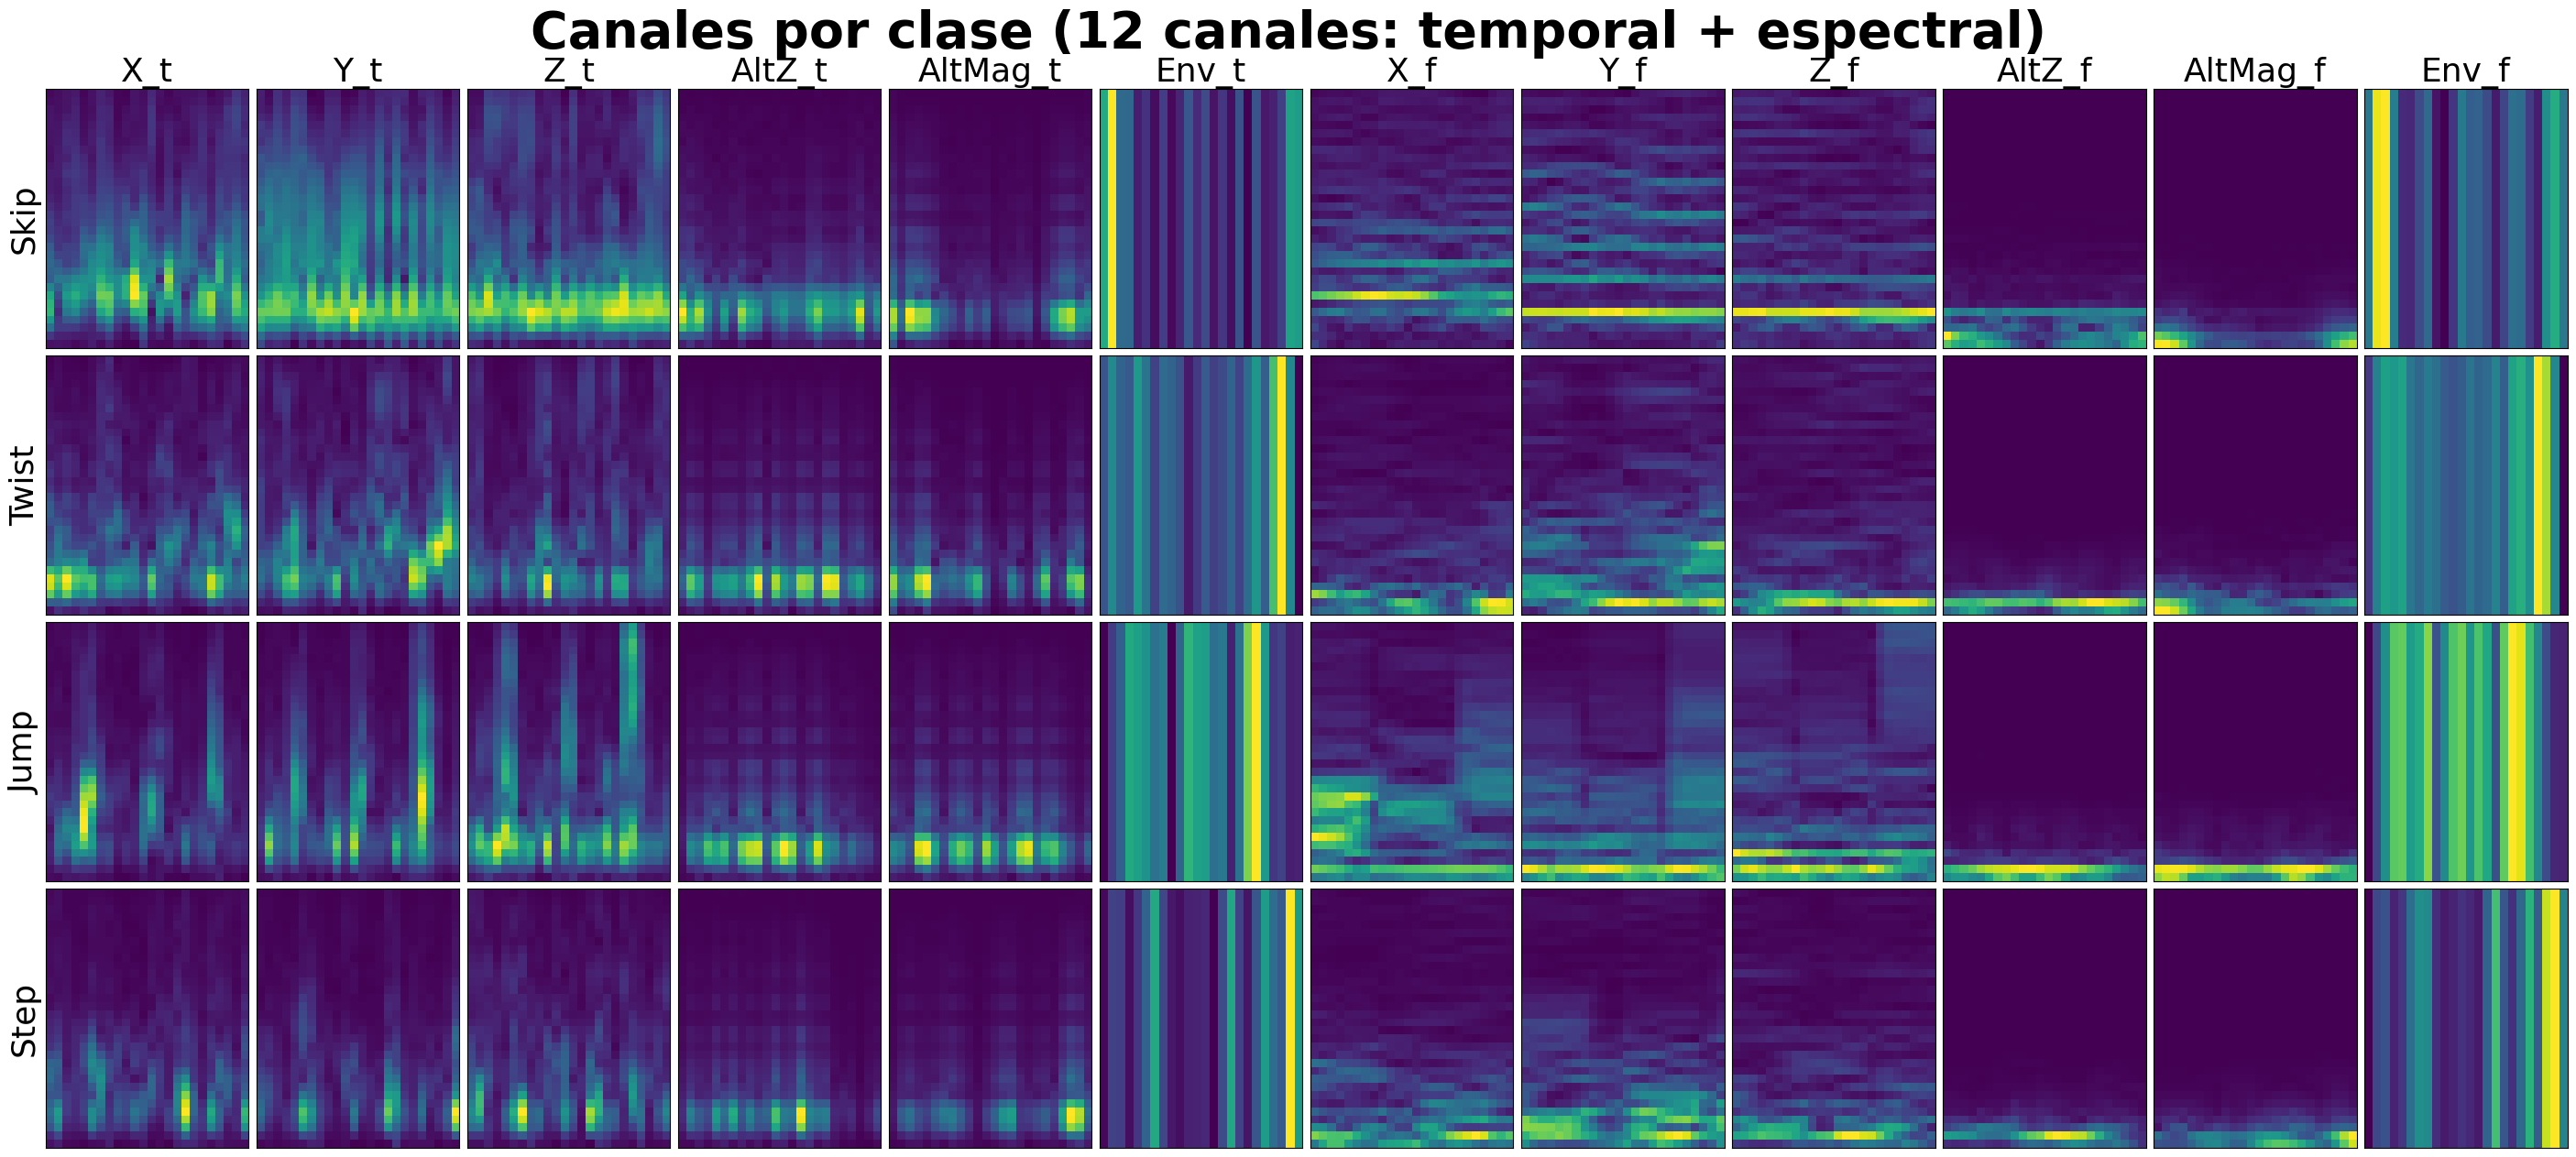

In [13]:
channel_names = [
    "X_t", "Y_t", "Z_t", "AltZ_t", "AltMag_t", "Env_t",
    "X_f", "Y_f", "Z_f", "AltZ_f", "AltMag_f", "Env_f"
]
class_ids = list(labels.keys())

# Tamaños grandes
suptitle_fs = 40
col_title_fs = 26
row_label_fs = 26

n_rows = len(class_ids)
n_cols = len(channel_names)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(28, 12), constrained_layout=True)

for row_i, lbl in enumerate(class_ids):
    subset = train_df[train_df[("META", "LABEL")] == lbl]

    if subset.empty:
        for col_i in range(n_cols):
            axs[row_i, col_i].axis("off")
        continue

    sample_row = subset.iloc[0]
    channels = generate_channels(sample_row)  # shape: (12, H, W)

    for col_i in range(n_cols):
        ax = axs[row_i, col_i]
        ax.imshow(channels[col_i], aspect="auto", origin="lower", cmap="viridis")
        ax.set_xticks([])
        ax.set_yticks([])

        if row_i == 0:
            ax.set_title(channel_names[col_i], fontsize=col_title_fs)
        if col_i == 0:
            ax.set_ylabel(labels[lbl], fontsize=row_label_fs)

plt.suptitle(
    "Canales por clase (12 canales: temporal + espectral)",
    y=1.04,
    fontsize=suptitle_fs,
    fontweight="bold"
)
plt.show()

## Modelo en PyTorch
En esta sección definimos una red neuronal dual en PyTorch. Cada rama de la red procesa una de las representaciones (temporal y espectral) y luego se combinan para realizar la clasificación final.

![](images/model.svg)

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from utils import ActivityCNN, ActivityDataset, train_model, validate_model

### Entrenamiento y validación
Con la arquitectura definida, se implementa un bucle de entrenamiento estándar con seguimiento de pérdida, accuracy y early stopping. La función de validación se reutiliza en train/val y en LOSO para mantener una métrica comparable en todos los experimentos.

In [15]:
device = torch.device("mps")  # Change to your available device
precompute_cache = False # True first time to fill cache

log_every = 5
show_batch_progress = False

train_cache_dir = "artifacts/cache/train"
val_cache_dir = "artifacts/cache/val"

train_ds = ActivityDataset(
    train_df,
    channel_fn=generate_channels,
    cache_dir=train_cache_dir,
    precompute=precompute_cache,
    is_training=True,
 )
val_ds = ActivityDataset(
    val_df,
    channel_fn=generate_channels,
    cache_dir=val_cache_dir,
    precompute=precompute_cache,
    is_training=False,
 )

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

model = ActivityCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=4, factor=0.7)

best_val_loss = float('inf')
patience = 15
patience_counter = 0

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "lr": [],
}

for epoch in range(80):
    train_loss, train_acc = train_model(
        model, train_loader, criterion, optimizer, device, show_batch_progress=show_batch_progress
    )
    val_loss, val_acc = validate_model(
        model, val_loader, criterion, device, show_batch_progress=show_batch_progress
    )
    scheduler.step(val_loss)

    lr_actual = optimizer.param_groups[0]['lr']

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(lr_actual)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    should_log = (epoch == 0) or ((epoch + 1) % log_every == 0) or improved
    if should_log:
        status = "BEST" if improved else f"pat={patience_counter}/{patience}"
        epoch_display = epoch + 1
        print(
            f"Ep {epoch_display:02d} | lr={lr_actual:.2e} | "
            f"train {train_loss:.4f}/{train_acc:.2f}% | "
            f"val {val_loss:.4f}/{val_acc:.2f}% | {status}"
        )

    if patience_counter >= patience:
        print(f"Early stopping en epoch {epoch + 1:02d}")
        model.load_state_dict(torch.load('best_model.pth'))
        break

Ep 01 | lr=5.00e-04 | train 0.8569/77.58% | val 0.6148/88.26% | BEST
Ep 02 | lr=5.00e-04 | train 0.5943/91.29% | val 0.5700/91.43% | BEST
Ep 03 | lr=5.00e-04 | train 0.5640/92.62% | val 0.5575/92.41% | BEST
Ep 04 | lr=5.00e-04 | train 0.5468/93.20% | val 0.5545/92.86% | BEST
Ep 05 | lr=5.00e-04 | train 0.5339/93.97% | val 0.6251/89.78% | pat=1/15
Ep 08 | lr=5.00e-04 | train 0.5079/95.33% | val 0.5283/93.75% | BEST
Ep 10 | lr=5.00e-04 | train 0.5040/95.13% | val 0.5508/92.81% | pat=2/15
Ep 14 | lr=3.50e-04 | train 0.4861/96.00% | val 0.5116/93.48% | BEST
Ep 15 | lr=3.50e-04 | train 0.4830/96.03% | val 0.5026/93.88% | BEST
Ep 20 | lr=2.45e-04 | train 0.4733/96.37% | val 0.5259/92.77% | pat=5/15
Ep 24 | lr=2.45e-04 | train 0.4638/96.89% | val 0.5013/93.75% | BEST
Ep 25 | lr=2.45e-04 | train 0.4626/96.97% | val 0.5202/92.99% | pat=1/15
Ep 26 | lr=2.45e-04 | train 0.4595/97.20% | val 0.4922/93.79% | BEST
Ep 30 | lr=2.45e-04 | train 0.4559/97.27% | val 0.5014/93.21% | pat=4/15
Ep 32 | lr=1.7

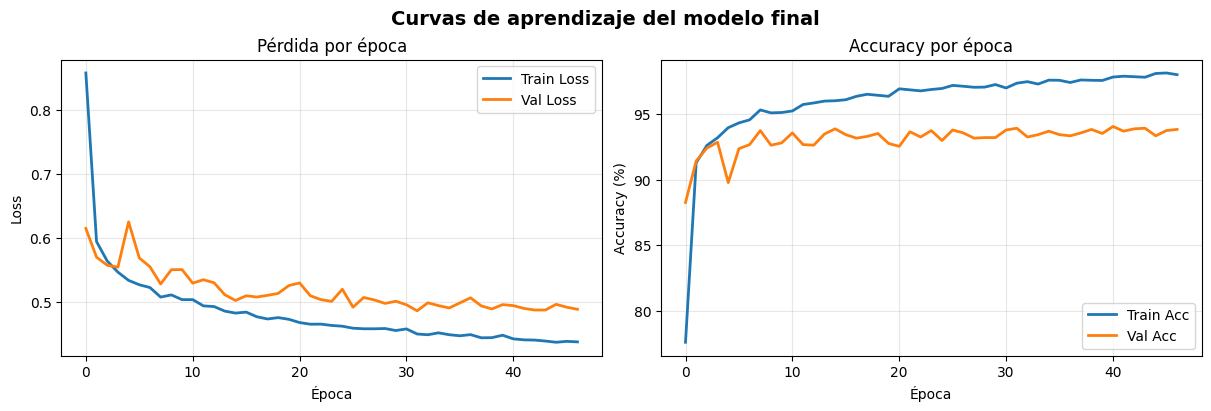

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

fig.suptitle("Curvas de aprendizaje del modelo final", fontsize=14, fontweight='bold')

axs[0].plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=2)
axs[0].plot(history["epoch"], history["val_loss"], label="Val Loss", linewidth=2)
axs[0].set_title("Pérdida por época")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(history["epoch"], history["train_acc"], label="Train Acc", linewidth=2)
axs[1].plot(history["epoch"], history["val_acc"], label="Val Acc", linewidth=2)
axs[1].set_title("Accuracy por época")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.show()

#### Algunas validaciones rápidas

In [17]:
train_ds_check = ActivityDataset(train_df, channel_fn=generate_channels, cache_dir="artifacts/cache/train", is_training=True)
val_ds_check = ActivityDataset(val_df, channel_fn=generate_channels, cache_dir="artifacts/cache/val", is_training=False)

x_train_1, y_train_1 = train_ds_check[0]
x_train_2, y_train_2 = train_ds_check[0]
x_val_1, y_val_1 = val_ds_check[0]
x_val_2, y_val_2 = val_ds_check[0]

assert x_train_1.ndim == 3 and x_val_1.ndim == 3, "Las muestras deben tener shape [C, H, W]"
assert x_train_1.shape == x_val_1.shape, "Train y Val deben tener la misma forma de entrada"
assert x_train_1.shape[0] == 12, "Se esperaban 12 canales de entrada"
assert not torch.equal(x_train_1, x_train_2), "Train deberia variar por SpecAugment (is_training=True)"
assert torch.equal(x_val_1, x_val_2), "Val deberia ser determinista (is_training=False)"
assert 0 <= y_train_1.item() < 4, "Etiqueta de train fuera de rango [0, 3]"
assert 0 <= y_val_1.item() < 4, "Etiqueta de val fuera de rango [0, 3]"

In [18]:
model_check = ActivityCNN(num_classes=4)
x_dummy = torch.randn(8, 12, 32, 24)
with torch.no_grad():
    out_dummy = model_check(x_dummy)

assert x_dummy.shape == (8, 12, 32, 24), "Input dummy con shape inesperado"
assert out_dummy.shape == (8, 4), "La salida del modelo debe ser [batch, num_classes] = [8, 4]"
assert torch.isfinite(out_dummy).all(), "La salida contiene NaN o Inf"

### Guardado del modelo

In [19]:
import json

In [20]:
os.makedirs("artifacts", exist_ok=True)

if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", map_location=device))

weights_path = "artifacts/activity_cnn_multires_weights.pth"
torch.save(model.state_dict(), weights_path)

checkpoint_path = "artifacts/activity_cnn_multires_checkpoint.pt"
checkpoint = {
    "model_state_dict": model.state_dict(),
    "num_classes": 4,
    "in_channels": 12,
    "target_shape": [32, 24],
    "labels": labels,
    "feature_mode": "multi_resolution_temporal_spectral",
}
torch.save(checkpoint, checkpoint_path)

model_cpu = ActivityCNN(num_classes=4)
model_cpu.load_state_dict(model.state_dict())
model_cpu.eval()
example = torch.randn(1, 12, 32, 24)
scripted = torch.jit.trace(model_cpu, example)
script_path = "artifacts/activity_cnn_multires_scripted.pt"
scripted.save(script_path)

meta_path = "artifacts/activity_cnn_multires_meta.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "weights_path": weights_path,
            "checkpoint_path": checkpoint_path,
            "script_path": script_path,
            "num_classes": 4,
            "in_channels": 12,
            "input_shape": [12, 32, 24],
            "labels": labels,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print("Archivos guardados:")
print("-", weights_path)
print("-", checkpoint_path)
print("-", script_path)
print("-", meta_path)

Archivos guardados:
- artifacts/activity_cnn_multires_weights.pth
- artifacts/activity_cnn_multires_checkpoint.pt
- artifacts/activity_cnn_multires_scripted.pt
- artifacts/activity_cnn_multires_meta.json


## Visualización de resultados
Mediante una matriz de confusión y un resumen de las métricas obtenidas, analizamos el rendimiento del modelo sobre el conjunto de validación del hold-out.

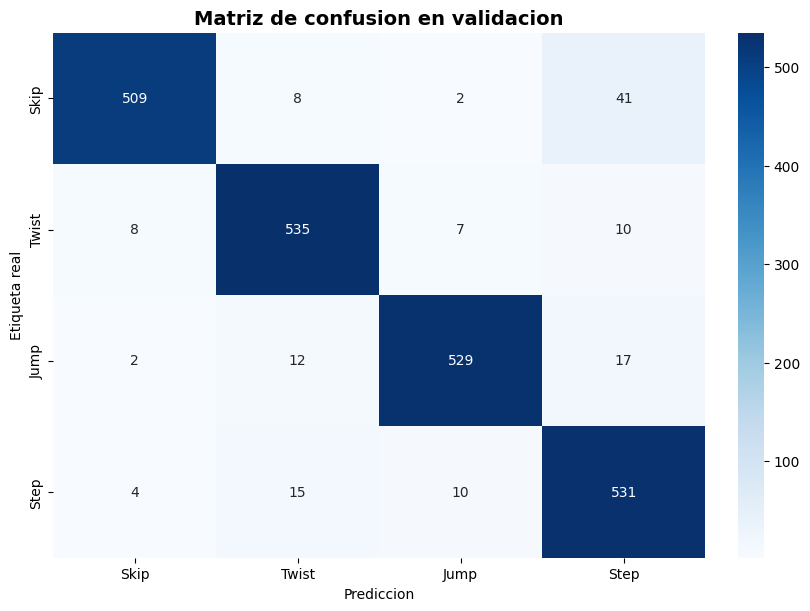

In [21]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    xticklabels=['Skip', 'Twist', 'Jump', 'Step'],
    yticklabels=['Skip', 'Twist', 'Jump', 'Step']
 )
ax.set_title('Matriz de confusion en validacion', fontsize=14, fontweight='bold')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Etiqueta real')
plt.show()

In [22]:
pd.DataFrame(classification_report(
    all_labels,
    all_preds,
    target_names=['Skip', 'Twist', 'Jump', 'Step'],
    output_dict=True
)).T

,precision,recall,f1-score,support
Skip,0.973231,0.908929,0.939982,560.000000
Twist,0.938596,0.955357,0.946903,560.000000
Jump,0.965328,0.944643,0.954874,560.000000
Step,0.886477,0.948214,0.916307,560.000000
accuracy,0.939286,0.939286,0.939286,0.939286
macro avg,0.940908,0.939286,0.939516,2240.000000
weighted avg,0.940908,0.939286,0.939516,2240.000000


# FASE 2: Validación de Generalización (LOSO)
En esta fase se ejecuta Leave-One-Subject-Out sobre el 100% de los sujetos del conjunto etiquetado para estimar la métrica real de generalización entre personas.

In [23]:
import warnings
warnings.filterwarnings('ignore')

In [24]:
from utils import (
    run_loso_validation,
    compute_loso_epoch_summary,
    compute_loso_subject_ranking,
    compute_loso_global_metrics,
    compute_loso_generalization_gap,
    compute_loso_top_subjects,
)

### Ejecucion LOSO por sujeto
Se ejecuta el bucle Leave-One-Subject-Out completo y se almacenan resultados e históricos por sujeto.

In [25]:
loso_results, loso_histories, all_loso_epochs = run_loso_validation(data, generate_channels, device)

LOSO sujetos: 100%|██████████| 31/31 [4:40:23<00:00, 542.68s/it, ultimo=S31=97.2%, media=95.6%]  


### Metricas globales de generalizacion
Se resumen accuracy media e intervalo de confianza del 95% sobre todos los sujetos LOSO.

In [26]:
loso_epoch_summary = compute_loso_epoch_summary(all_loso_epochs)
loso_subject_ranking = compute_loso_subject_ranking(loso_results)
loso_global_stats = compute_loso_global_metrics(loso_results, confidence_level=0.95)
loso_gap_stats = compute_loso_generalization_gap(all_loso_epochs)

loso_top3 = compute_loso_top_subjects(loso_results, top_k=3)

#### Accuracy media LOSO
Salida puntual de la accuracy media sobre sujetos.

In [27]:
pd.DataFrame([
    {
        "Metrica": "Accuracy media LOSO",
        "Valor": round(float(loso_global_stats["mean_acc"]), 4),
    }
])

,Metrica,Valor
0,Accuracy media LOSO,95.6048


#### Intervalo de confianza 95%
Salida puntual del intervalo de confianza para la accuracy media.

In [28]:
pd.DataFrame([
    {
        "Metrica": "IC 95%",
        "Limite_inferior": round(float(loso_global_stats["ci_lower"]), 4),
        "Limite_superior": round(float(loso_global_stats["ci_upper"]), 4),
    }
])

,Metrica,Limite_inferior,Limite_superior
0,IC 95%,94.6162,96.5934


#### Top 3 sujetos
Salida puntual con los tres sujetos de mejor accuracy en LOSO.

In [29]:
loso_top3[["subject_id", "accuracy"]].rename(
    columns={"subject_id": "Sujeto", "accuracy": "Accuracy"}
).reset_index(drop=True)

,Sujeto,Accuracy
0,20,99.0625
1,15,99.0625
2,5,98.7500


### Convergencia media durante el entrenamiento
Comparación de curvas promedio Train/Test para accuracy y loss en las iteraciones LOSO.

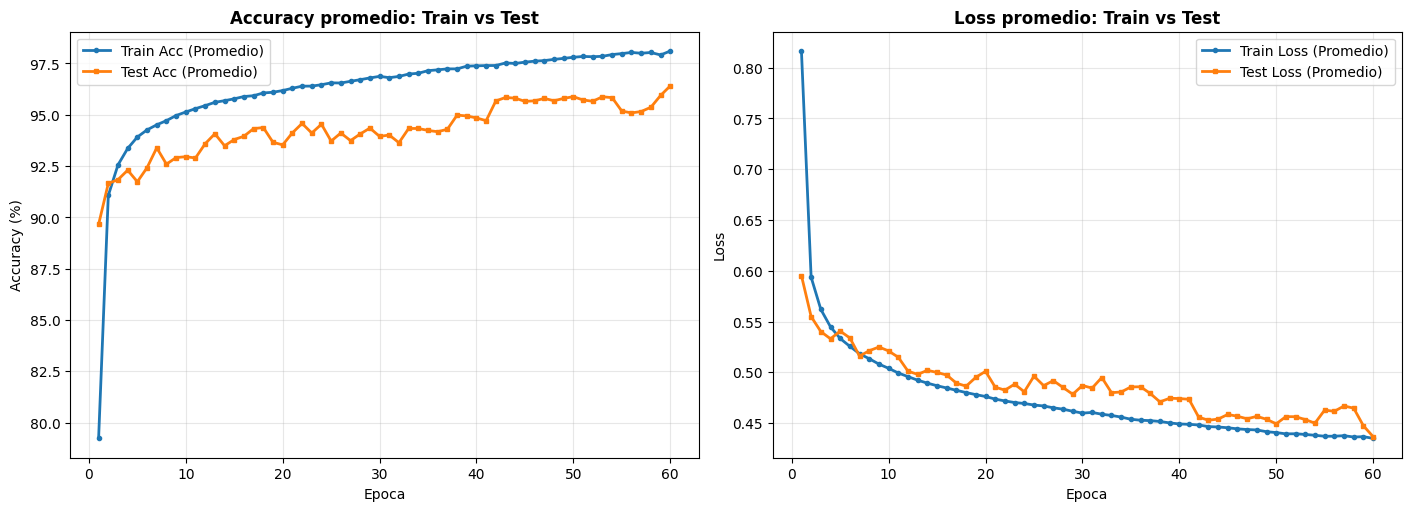

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axs[0].plot(
    loso_epoch_summary["Epoch"],
    loso_epoch_summary["Avg_Train_Acc"],
    label="Train Acc (Promedio)",
    marker="o",
    markersize=3,
    linewidth=2,
)
axs[0].plot(
    loso_epoch_summary["Epoch"],
    loso_epoch_summary["Avg_Test_Acc"],
    label="Test Acc (Promedio)",
    marker="s",
    markersize=3,
    linewidth=2,
)
axs[0].set_title("Accuracy promedio: Train vs Test", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Accuracy (%)")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(
    loso_epoch_summary["Epoch"],
    loso_epoch_summary["Avg_Train_Loss"],
    label="Train Loss (Promedio)",
    marker="o",
    markersize=3,
    linewidth=2,
)
axs[1].plot(
    loso_epoch_summary["Epoch"],
    loso_epoch_summary["Avg_Test_Loss"],
    label="Test Loss (Promedio)",
    marker="s",
    markersize=3,
    linewidth=2,
)
axs[1].set_title("Loss promedio: Train vs Test", fontsize=12, fontweight="bold")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.show()

### Desempeño individual por sujeto
Ranking horizontal de sujetos de mejor a peor con referencia de la media global.

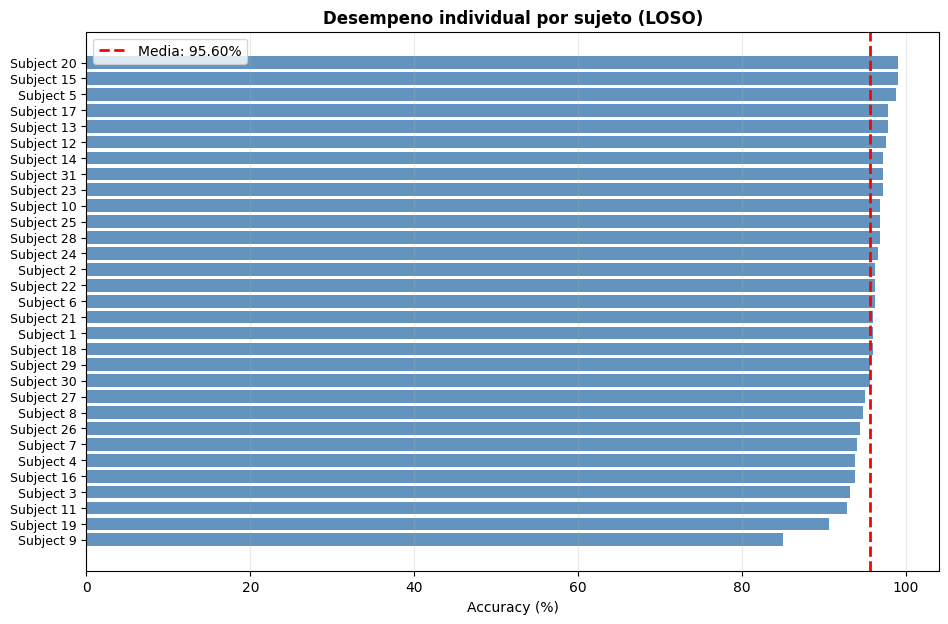

In [31]:
import numpy as np
import matplotlib.pyplot as plt

ordered = loso_subject_ranking.sort_values("accuracy", ascending=False).reset_index(drop=True)
mean_acc = loso_global_stats["mean_acc"]

plt.figure(figsize=(11, 7))
plt.barh(
    range(len(ordered)),
    ordered["accuracy"].values,
    color="steelblue",
    alpha=0.85,
)
plt.axvline(mean_acc, color="red", linestyle="--", linewidth=2, label=f"Media: {mean_acc:.2f}%")
plt.yticks(range(len(ordered)), [f"Subject {s}" for s in ordered["subject_id"].values], fontsize=9)
plt.gca().invert_yaxis()
plt.xlabel("Accuracy (%)")
plt.title("Desempeno individual por sujeto (LOSO)", fontsize=12, fontweight="bold")
plt.legend()
plt.grid(alpha=0.25, axis="x")
plt.show()

### Estabilidad inter-sujeto
Curva de test promedio con banda de desviación estandar para visualizar robustez del modelo.

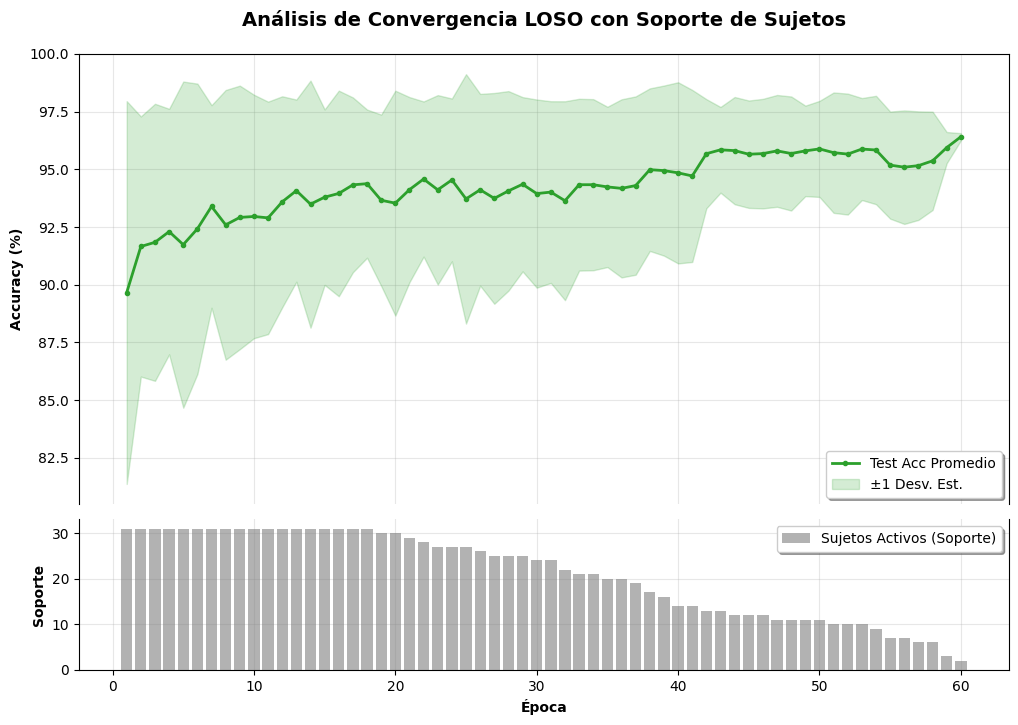

In [32]:
epochs = loso_epoch_summary["Epoch"].to_numpy()
mean_test = loso_epoch_summary["Avg_Test_Acc"].to_numpy()
std_test = loso_epoch_summary["Std_Test_Acc"].to_numpy()

soporte = []
for ep_idx in range(len(epochs)):
    count = sum(1 for h in all_loso_epochs if ep_idx < len(h["history"]["epoch"]))
    soporte.append(count)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05) 

# SUBPLOT SUPERIOR
ax1.plot(epochs, mean_test, color='#2ca02c', label="Test Acc Promedio", linewidth=2, marker='o', markersize=3)
ax1.fill_between(epochs, mean_test - std_test, mean_test + std_test, alpha=0.2, color='#2ca02c', label="±1 Desv. Est.")
ax1.set_ylabel("Accuracy (%)", fontweight='bold')
ax1.set_title("Análisis de Convergencia LOSO con Soporte de Sujetos", fontsize=14, fontweight='bold', pad=20)

# SUBPLOT INFERIOR
ax2.bar(epochs, soporte, color='#7f7f7f', alpha=0.6, label="Sujetos Activos (Soporte)", width=0.8)
ax2.set_ylabel("Soporte", fontweight='bold')
ax2.set_xlabel("Época", fontweight='bold')
ax2.set_ylim(0, max(soporte) + 2)

for ax in [ax1, ax2]:
    ax.grid(True, which='both', linestyle='-', alpha=0.3)
    ax.set_axisbelow(True)

ax1.legend(loc="lower right", frameon=True, shadow=True)
ax2.legend(loc="upper right", frameon=True, shadow=True)

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(bottom=False)

plt.show()

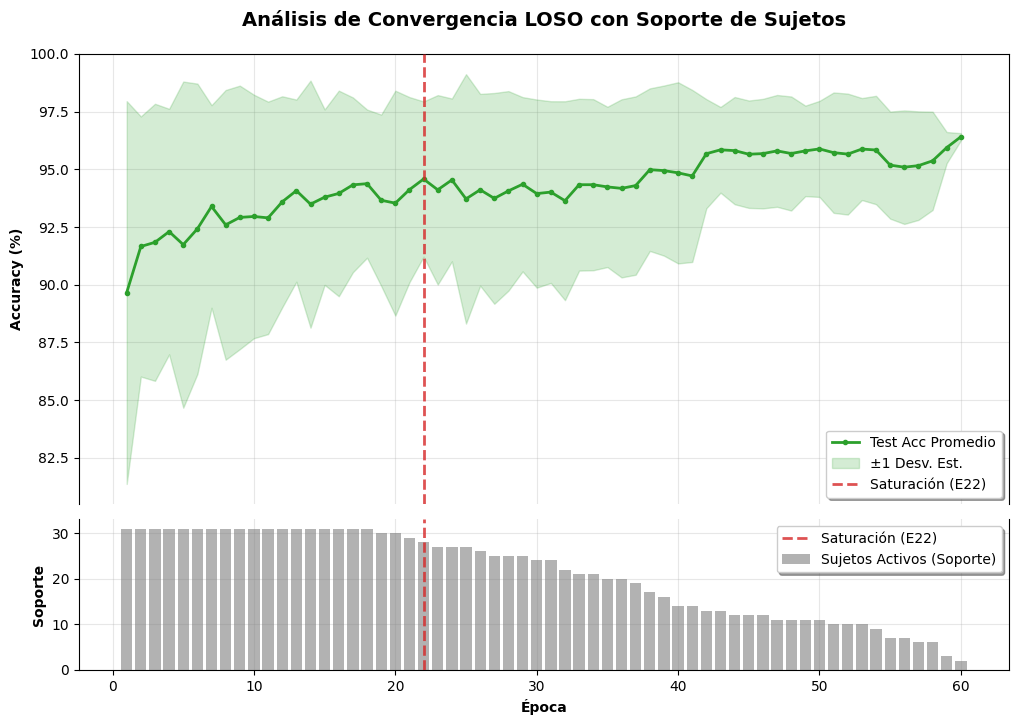

In [33]:
loso_saturation_epoch = 22  # Elegir saturación en base al gráfico previo

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05) 

# SUBPLOT SUPERIOR
ax1.plot(epochs, mean_test, color='#2ca02c', label="Test Acc Promedio", linewidth=2, marker='o', markersize=3)
ax1.fill_between(epochs, mean_test - std_test, mean_test + std_test, alpha=0.2, color='#2ca02c', label="±1 Desv. Est.")
ax1.set_ylabel("Accuracy (%)", fontweight='bold')
ax1.set_title("Análisis de Convergencia LOSO con Soporte de Sujetos", fontsize=14, fontweight='bold', pad=20)

# SUBPLOT INFERIOR
ax2.bar(epochs, soporte, color='#7f7f7f', alpha=0.6, label="Sujetos Activos (Soporte)", width=0.8)
ax2.set_ylabel("Soporte", fontweight='bold')
ax2.set_xlabel("Época", fontweight='bold')
ax2.set_ylim(0, max(soporte) + 2)


for ax in [ax1, ax2]:
    ax.axvline(loso_saturation_epoch, color="#d62728", linestyle="--", 
                linewidth=2, alpha=0.8, zorder=5, label=f"Saturación (E{loso_saturation_epoch})")

for ax in [ax1, ax2]:
    ax.grid(True, which='both', linestyle='-', alpha=0.3)
    ax.set_axisbelow(True)

ax1.legend(loc="lower right", frameon=True, shadow=True)
ax2.legend(loc="upper right", frameon=True, shadow=True)

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(bottom=False)

plt.show()

# FASE 3: Modelo de Producción
Se entrena un nuevo modelo con el 100% del conjunto etiquetado usando el número de épocas óptimo detectado en la fase LOSO.

In [34]:
production_epochs = loso_saturation_epoch

In [35]:
production_cache_dir = "artifacts/cache/production"

production_ds = ActivityDataset(
    data,
    channel_fn=generate_channels,
    cache_dir=production_cache_dir,
    precompute=precompute_cache,
    is_training=True,
)
production_loader = DataLoader(production_ds, batch_size=32, shuffle=True, num_workers=0)

production_model = ActivityCNN(num_classes=4).to(device)
production_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
production_optimizer = torch.optim.Adam(production_model.parameters(), lr=0.0005, weight_decay=1e-3)

production_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
}

for epoch in range(production_epochs):
    train_loss_prod, train_acc_prod = train_model(
        production_model,
        production_loader,
        production_criterion,
        production_optimizer,
        device,
        show_batch_progress=False,
    )

    production_history["epoch"].append(epoch + 1)
    production_history["train_loss"].append(train_loss_prod)
    production_history["train_acc"].append(train_acc_prod)

production_history_df = pd.DataFrame(production_history)
production_history_df

,epoch,train_loss,train_acc
0,1,0.802915,80.715726
1,2,0.589996,91.300403
2,3,0.559736,92.701613
3,4,0.543796,93.276210
4,5,0.536011,93.780242
5,6,0.525337,94.153226
6,7,0.519356,94.455645
7,8,0.513232,94.606855
8,9,0.511639,94.717742
9,10,0.505101,94.909274


### Guardado del modelo de produccion
Se exportan los pesos y el checkpoint del modelo entrenado con todos los datos.

In [36]:
production_weights_path = "artifacts/activity_cnn_production_weights.pth"
production_checkpoint_path = "artifacts/activity_cnn_production_checkpoint.pt"

production_checkpoint = {
    "model_state_dict": production_model.state_dict(),
    "num_classes": 4,
    "in_channels": 12,
    "target_shape": [32, 24],
    "labels": labels,
    "feature_mode": "full_training_after_loso",
    "epochs": production_epochs,
    "history": production_history,
}

torch.save(production_model.state_dict(), production_weights_path)
torch.save(production_checkpoint, production_checkpoint_path)

pd.DataFrame([
    {
        "Artefacto": "Pesos produccion",
        "Ruta": production_weights_path,
    },
    {
        "Artefacto": "Checkpoint produccion",
        "Ruta": production_checkpoint_path,
    },
])

,Artefacto,Ruta
0,Pesos produccion,artifacts/activity_cnn_production_weights.pth
1,Checkpoint produccion,artifacts/activity_cnn_production_checkpoint.pt


## Predicciones finales sobre `predict`
Se generan predicciones para el conjunto sin etiquetas y se exportan a un CSV nuevo.

In [37]:
inference_model = production_model
inference_model.eval()

predict_cache_dir = "artifacts/cache/predict"
os.makedirs(predict_cache_dir, exist_ok=True)

predict_tensors = []
for idx in range(len(predict)):
    cache_path = os.path.join(predict_cache_dir, f"sample_{idx:06d}.pt")
    if os.path.exists(cache_path):
        x_tensor = torch.load(cache_path, map_location="cpu")
    else:
        row = predict.iloc[idx]
        x_data = generate_channels(row)
        x_tensor = torch.from_numpy(x_data).float()
        torch.save(x_tensor, cache_path)
    predict_tensors.append(x_tensor)

x_predict = torch.stack(predict_tensors, dim=0)
predict_loader = DataLoader(x_predict, batch_size=64, shuffle=False)

pred_labels = []
with torch.no_grad():
    for xb in predict_loader:
        logits = inference_model(xb.to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy() + 1
        pred_labels.extend(preds.tolist())

submission_df = pd.DataFrame({"y_test_pred": pred_labels})
assert len(submission_df) == len(predict), "El numero de predicciones no coincide con el test oficial"
assert submission_df["y_test_pred"].between(1, 4).all(), "Hay etiquetas fuera de [1, 4]"

submission_path = "artifacts/predict_labels.csv"
submission_df.to_csv(submission_path, index=False)

print(f"CSV generado: {submission_path}")
submission_df.head()

CSV generado: artifacts/predict_labels.csv


,y_test_pred
0,3
1,2
2,1
3,3
4,2


In [38]:
submission_df.value_counts()

y_test_pred
3              1299
4              1293
2              1281
1              1247
Name: count, dtype: int64